Saved figure to figures/example_fieldlines.png


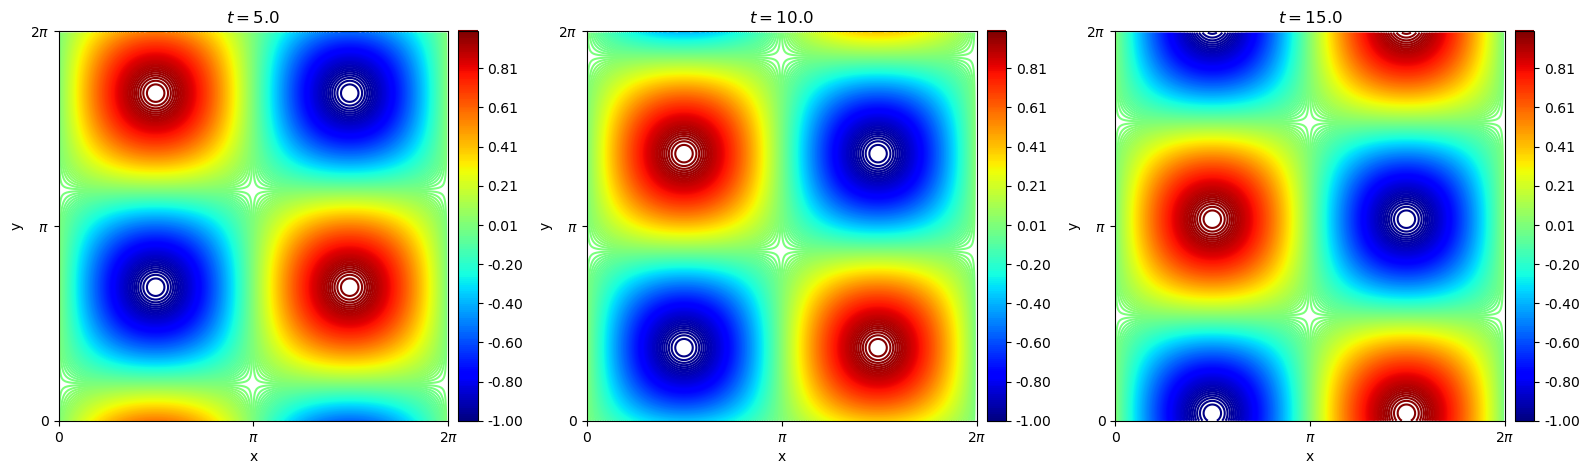

In [3]:
#!/usr/bin/env python3
"""
Example script to plot 2D field contours at three selected times.

This version runs with synthetic data so it can execute without
proprietary solvers or data classes.`load_data()` can be replaced.

"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1 import make_axes_locatable
from pathlib import Path

# ---------------------------------------------------------------------------
# Synthetic data (as an example)
# ---------------------------------------------------------------------------
def load_data(nx=256, ny=256, nt=50):
    """Return synthetic field data and time array for demonstration."""
    x = np.linspace(0, 2*np.pi, nx)
    y = np.linspace(0, 2*np.pi, ny)
    X, Y = np.meshgrid(x, y)
    tarray = np.linspace(0, 20, nt)
    # Example evolving field (like vector potential)
    afield = [np.sin(X) * np.cos(Y + 0.2*t) for t in tarray]
    return np.array(afield), tarray

# ---------------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------------
def tpi(tplot, tarray):
    """Return index of the nearest time in tarray to the desired tplot."""
    return int(np.argmin(np.abs(tarray - tplot)))

def make_colorbar(ax_, im_):
    """Attach a colorbar to the contour plot."""
    divider = make_axes_locatable(ax_)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    cbar = plt.colorbar(im_, cax=cax)
    cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
    return cbar

def plot_axis(ax, N):
    """Format axes with π labels."""
    ax.set_xticks([0, int(N/2), N])
    ax.set_xticklabels(["0", r"$\pi$", r"$2\pi$"])
    ax.set_yticks([0, int(N/2), N])
    ax.set_yticklabels(["0", r"$\pi$", r"$2\pi$"])
    ax.set_xlabel("x")
    ax.set_ylabel("y")

# ---------------------------------------------------------------------------
# Main plotting routine
# ---------------------------------------------------------------------------
def main():
    # Load data
    data, tarray = load_data()
    N = data.shape[-1]

    # Times to plot
    tplot = [5, 10, 15]
    tp = [tpi(t, tarray) for t in tplot]

    # Extract snapshots of field
    fields = [data[i] for i in tp]

    # Global contour levels to avoid clipping
    vmin = min(np.min(f) for f in fields)
    vmax = max(np.max(f) for f in fields)
    cont_levels = np.linspace(vmin, vmax, 200)
    contour_opts = {"levels": cont_levels}

    # Create figure
    fig, ax = plt.subplots(1, 3, figsize=(16, 5))
    fig.subplots_adjust(wspace=0.25)

    for i, (field, t) in enumerate(zip(fields, tplot)):
        im = ax[i].contour(field, cmap="jet", **contour_opts)
        ax[i].set_aspect("equal")
        make_colorbar(ax[i], im)
        plot_axis(ax[i], N)
        ax[i].set_title(fr"$t = {np.ceil(t*10)/10}$")

    fig.tight_layout()

    # Save figure
    outdir = Path("figures")
    outdir.mkdir(exist_ok=True)
    outfile = outdir / "example_fieldlines.png"
    fig.savefig(outfile, dpi=300)
    print(f"Saved figure to {outfile}")
    plt.show()

# ---------------------------------------------------------------------------
if __name__ == "__main__":
    main()
